In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("diabetes.csv")

# Display first 5 rows
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
import numpy as np

# Columns where 0 is considered invalid
invalid_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

# Count zero values
for col in invalid_columns:
    print(f"{col}: {(df[col] == 0).sum()}")

# Replace zeros with NaN
df[invalid_columns] = df[invalid_columns].replace(0, np.nan)

# Check missing values
print(df.isnull().sum())

Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [ ]:
from sklearn.impute import SimpleImputer

# Create imputer
imputer = SimpleImputer(strategy='median')

# Fill missing values
df[invalid_columns] = imputer.fit_transform(df[invalid_columns])

# Verify missing values
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
# Correlation matrix
correlation = df.corr()

print(correlation)

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.128213       0.208615       0.081770   
Glucose                      0.128213  1.000000       0.218937       0.192615   
BloodPressure                0.208615  0.218937       1.000000       0.191892   
SkinThickness                0.081770  0.192615       0.191892       1.000000   
Insulin                      0.025047  0.419451       0.045363       0.155610   
BMI                          0.021559  0.231049       0.281257       0.543205   
DiabetesPedigreeFunction    -0.033523  0.137327      -0.002378       0.102188   
Age                          0.544341  0.266909       0.324915       0.126107   
Outcome                      0.221898  0.492782       0.165723       0.214873   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies               0.025047  0.021559                 -0.033523   
Glucose                   0.419451  0.231

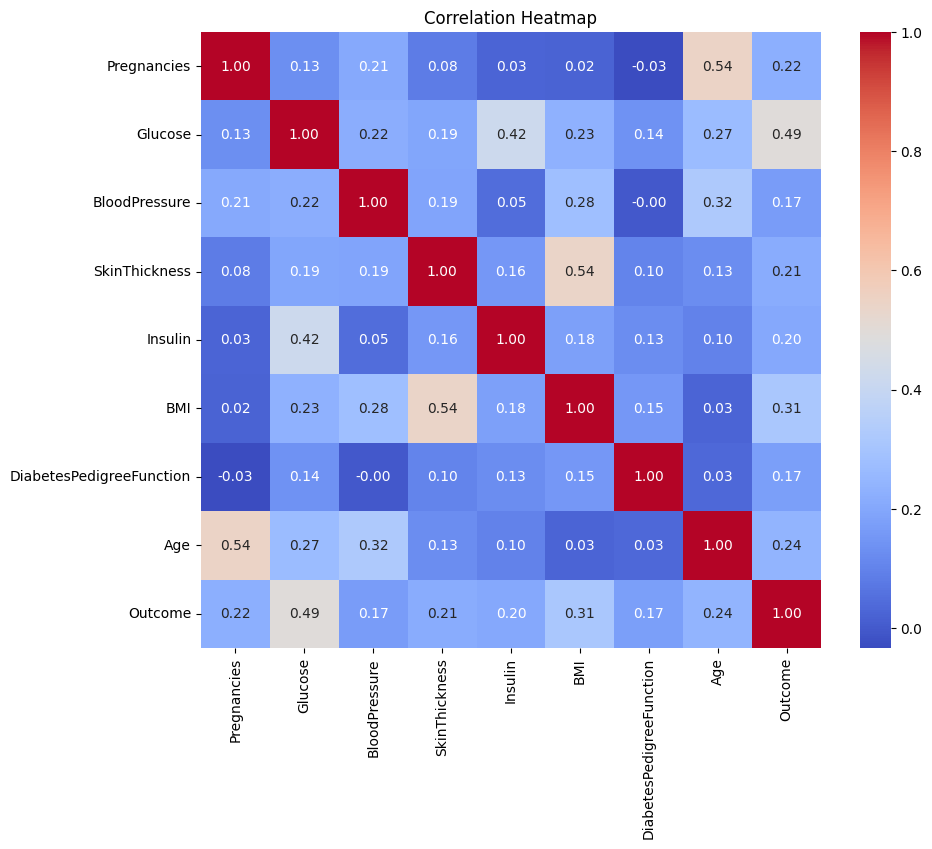

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
from sklearn.metrics.pairwise import (
    euclidean_distances,
    manhattan_distances,
    cosine_similarity
)

# Select first three observations
sample = df.iloc[0:3, :-1]

print("Euclidean Distance")
print(euclidean_distances(sample))

print("\nManhattan Distance")
print(manhattan_distances(sample))

print("\nCosine Similarity")
print(cosine_similarity(sample))

Euclidean Distance
[[ 0.         66.90348403 41.94153103]
 [66.90348403  0.         98.33103803]
 [41.94153103 98.33103803  0.        ]]

Manhattan Distance
[[  0.    106.276  79.345]
 [106.276   0.    111.621]
 [ 79.345 111.621   0.   ]]

Cosine Similarity
[[1.         0.96837733 0.98598961]
 [0.96837733 1.         0.93084899]
 [0.98598961 0.93084899 1.        ]]


In [ ]:
print("Original Data")
print(df.iloc[:, :-1].head())

print("\nStandardized Data")
print(scaled_df.head())

print("\nOriginal Statistics")
print(df.iloc[:, :-1].describe())

print("\nStandardized Statistics")
print(scaled_df.describe())

Original Data
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

Standardized Data
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.639947  0.866045      -0.031990       0.670643 -0.181541  0.166619   
1    -0.844885 -1.205066      -0.528319      -0.012301 -0.181541 -0.852200   
2     1.233880  2.016662      -0.693761      -0.012301 -0.181541 -1.332500   
3    -0.8448

In [ ]:
print("Interpretation:")
print("1. Positive correlation indicates that two variables increase together.")
print("2. Negative correlation indicates that one variable increases while the other decreases.")
print("3. Correlation values near 0 indicate little or no linear relationship.")
print("4. Euclidean distance measures the straight-line distance between observations.")
print("5. Manhattan distance measures the city-block distance between observations.")
print("6. Cosine similarity measures the similarity in direction between observations.")
print("7. Standardization makes all features comparable by giving them the same scale.")

Interpretation:
1. Positive correlation indicates that two variables increase together.
2. Negative correlation indicates that one variable increases while the other decreases.
3. Correlation values near 0 indicate little or no linear relationship.
4. Euclidean distance measures the straight-line distance between observations.
5. Manhattan distance measures the city-block distance between observations.
6. Cosine similarity measures the similarity in direction between observations.
7. Standardization makes all features comparable by giving them the same scale.
